<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/spatial/01_veri_mutfagi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Veri mutfağı: Visium

Üçüncü proje: uzamsal transkriptomik. Visium platformunda doku kesiti, üzerinde barkodlu noktalar (spot) taşıyan bir lam üstüne yerleştirilir; her spot 55 mikrometre çapındadır ve altına denk gelen 1-10 hücrenin RNA'sını birlikte yakalar. Bu yüzden temel kural değişiyor: önceki seride matrisin her satırı bir hücreydi, burada her satır bir **nokta** — ve her noktanın doku üzerinde bir koordinatı var. Bu defterin işi mutfak: veriyi indir, yapısını tanı, kaliteye bak, arşivlik dosyayı üret.

In [1]:
%pip install -q scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


## 1. Kaynak ve klasör düzeni

Veri, 10x Genomics'in halka açık **V1_Adult_Mouse_Brain** seti: yetişkin fare beyninin koronal kesiti (CC-BY lisansı). Beş dosyayı Sheffield Bioinformatics Core'un eğitim deposundaki aynadan indiriyoruz ve Cell Ranger'ın standart klasör düzenine yerleştiriyoruz, çünkü `sc.read_visium` bu düzeni bekler:

- `filtered_feature_bc_matrix.h5` — spot × gen sayım matrisi
- `spatial/tissue_positions.csv` — her spotun doku üzerindeki koordinatları
- `spatial/scalefactors_json.json` — koordinatları görüntü piksellerine çeviren ölçek katsayıları
- `spatial/tissue_hires_image.png` ve `tissue_lowres_image.png` — kesitin fotoğrafları

`sc.read_visium` bunların hepsini tek AnnData'da toplar: sayımlar `X`'te, koordinatlar `obsm['spatial']`de, görüntüler ve ölçek katsayıları `uns['spatial']`de. `var_names_make_unique` önceki serilerden tanıdık: gen adları benzersiz değildir.

In [2]:
import warnings; warnings.filterwarnings('ignore')
import urllib.request, os
import scanpy as sc
import numpy as np

os.makedirs('visium/spatial', exist_ok=True)
KOK = 'https://raw.githubusercontent.com/sheffield-bioinformatics-core/spatial_transcriptomics_tutorial/main/Mouse-Brain-Coronal-Section/outs'
dosyalar = ['filtered_feature_bc_matrix.h5', 'spatial/tissue_positions.csv',
            'spatial/scalefactors_json.json', 'spatial/tissue_hires_image.png',
            'spatial/tissue_lowres_image.png']
for d in dosyalar:
    urllib.request.urlretrieve(f'{KOK}/{d}', f'visium/{d}')

v = sc.read_visium('visium')
v.var_names_make_unique()
kutuphane = list(v.uns['spatial'].keys())[0]
print('spot × gen:', v.shape, '| kütüphane:', kutuphane)
print('görüntüler:', list(v.uns['spatial'][kutuphane]['images'].keys()))
print('koordinatlar:', v.obsm['spatial'].shape)

spot × gen: (2702, 32285) | kütüphane: V1_Adult_Mouse_Brain
görüntüler: ['hires', 'lowres']
koordinatlar: (2702, 2)


## 2. Spot düzeyinde kalite ölçüleri

Ölçüler öncekiyle aynı üçlü — toplam UMI, tespit edilen gen, mitokondriyal yüzde — ama iki fark var. Birincisi tür: fare genlerinde mitokondriyal önek küçük harfli `mt-` yazılır (insanda `MT-` idi); öneki yanlış yazarsanız sıfır mitokondriyal gen bulursunuz ve hata mesajı almazsınız. İkincisi ölçek: bir spot birden çok hücre içerdiği için spot başına sayımlar, hücre başına sayımların birkaç katı çıkacak.

In [3]:
v.var['mt'] = v.var_names.str.startswith('mt-')
print('Mitokondriyal gen:', int(v.var['mt'].sum()))

sc.pp.calculate_qc_metrics(v, qc_vars=['mt'], inplace=True, percent_top=None, log1p=False)
print('Spot başına medyan UMI:', int(np.median(v.obs.total_counts)),
      '| medyan gen:', int(np.median(v.obs.n_genes_by_counts)))
print('Medyan MT%%: %.1f' % v.obs.pct_counts_mt.median())

Mitokondriyal gen: 13
Spot başına medyan UMI: 28943 | medyan gen: 6018
Medyan MT%: 15.3


## 3. Eşik dokuya göre seçilir

Koşumda medyan MT yüzdesi 15,3. PBMC'de bu sayı 2 idi ve yüzde 10'u eşik yapmıştık; burada aynı eşiği uygulasaydık sağlıklı dokunun yarıdan fazlasını çöpe atardık. Sebep teknik değil biyolojik: nöronlar enerji tüketimi yüksek hücrelerdir ve mitokondrileri boldur. İkinci serinin kuralı burada sayısıyla doğrulanıyor — MT eşiği evrensel değildir, dokunun biyolojisine göre seçilir ve gerekçesiyle raporlanır. Bu dokuda MT filtresi koymuyoruz; yalnız üç spottan azında görülen genleri eliyoruz.

In [4]:
once = v.shape
sc.pp.filter_genes(v, min_cells=3)
print('gen filtresi:', once, '->', v.shape)

gen filtresi: (2702, 32285) -> (2702, 19653)


## 4. Doku üstünde ilk bakış

Bu serinin yeni aracı: `sc.pl.spatial`, verilen obs sütununu doku fotoğrafının üzerine, her spotu kendi koordinatında boyayarak çizer; koordinatları görüntü piksellerine `scalefactors` çevirir. İlk boyamayı kalite ölçüleriyle yapıyoruz. Dikkatle bakın: sayımlar doku üzerinde rastgele mi dağılıyor, yoksa anatomiyi mi izliyor? Bu sorunun cevabı, serinin geri kalanının ön izlemesidir.

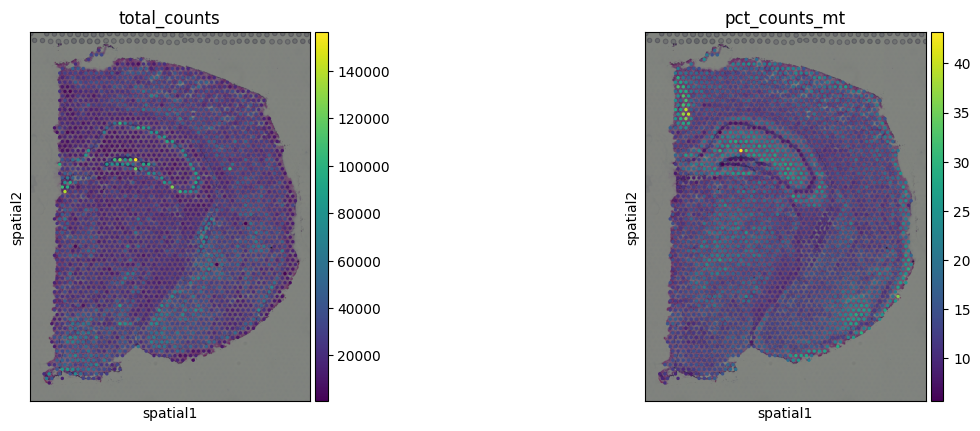

In [5]:
sc.pl.spatial(v, color=['total_counts', 'pct_counts_mt'])

## 5. Arşiv dosyası

Dosya önceki serininkinden büyük (180 MB civarı) çünkü spotlar derin dizilenmiş ve doku görüntüleri de dosyanın içinde taşınıyor; Zenodo için sorun değil.

In [6]:
v.write('spatial_ders.h5ad')
print('spatial_ders.h5ad: %.1f MB' % (os.path.getsize('spatial_ders.h5ad') / 1e6))

spatial_ders.h5ad: 181.6 MB


## Kendin dene

Üç görev. Birincisi: kendi koşunuzdan spot × gen boyutlarını, medyan UMI ve gen sayısını, medyan MT yüzdesini not edin. İkincisi, tek cümle: PBMC'deki yüzde 10'luk MT eşiği bu dokuya uygulansaydı ne olurdu ve bu neden yanlış olurdu? Üçüncüsü: `spatial_ders.h5ad` dosyasını Zenodo'ya **yeni bir kayıt** olarak yükleyin — önceki kayda sürüm eklemek değil, ayrı kayıt: kaynak ve atıf farklı. Başlıkta proje adı, açıklamada 10x Genomics "V1_Adult_Mouse_Brain" atfı ve CC-BY lisansı; Publish sonrası DOI'yi defterinizle birlikte gönderin. 3.2 o adresle açılacak.